# Transfer learning con ResNet18

En este notebook se implementa una estrategia de transferencia de aprendizaje utilizando una red preentrenada ResNet18 para la clasificación de emociones faciales.  
El objetivo es comparar su desempeño con la CNN base previamente entrenada y verificar si una arquitectura más robusta mejora la capacidad de generalización del modelo.

## Importación de librerías

En esta sección se cargan las librerías necesarias para reconstruir el conjunto de datos, preparar las imágenes, utilizar una red preentrenada y entrenar el modelo.  
Se emplean herramientas de PyTorch para el modelado y `scikit-learn` para la partición de los datos.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

## Verificación del dispositivo

Aquí se identifica si el entrenamiento se realizará en CPU o GPU.  
Esto es importante porque el uso de GPU puede reducir considerablemente el tiempo de entrenamiento, especialmente al trabajar con redes neuronales convolucionales y modelos preentrenados.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo en uso:", device)

Dispositivo en uso: cpu


## Reconstrucción de variables base

En esta parte se vuelve a definir la ruta del dataset y las clases emocionales presentes en el problema.  
Se reconstruyen también los diccionarios de conversión entre etiquetas de texto e índices numéricos, con el fin de que el notebook pueda ejecutarse de forma independiente.

## Construcción de la tabla base del dataset

En esta sección se genera una tabla que contiene la ruta de cada imagen y su clase correspondiente.  
Esta estructura facilita la partición estratificada del conjunto de datos y la posterior creación de datasets y DataLoaders para el entrenamiento del modelo.

## Partición del dataset

Aquí se divide el conjunto de datos en tres subconjuntos: entrenamiento, validación y prueba.  
La partición se realiza de manera estratificada para conservar la proporción de cada emoción en los tres subconjuntos, lo que ayuda a mantener una evaluación más equilibrada y consistente.

In [5]:
ruta_dataset = Path("C:/Users/adria/OneDrive/Documentos/ESCOM/6 SEMESTRE/ADA/Proj_2Parcial/data/raw")

clases = sorted([carpeta.name for carpeta in ruta_dataset.iterdir() if carpeta.is_dir()])
clase_a_indice = {clase: idx for idx, clase in enumerate(clases)}
indice_a_clase = {idx: clase for clase, idx in clase_a_indice.items()}

registros_dataset = []

for clase in clases:
    carpeta_clase = ruta_dataset / clase
    imagenes = list(carpeta_clase.glob("*.jpg"))
    
    for img_path in imagenes:
        registros_dataset.append({
            "ruta": str(img_path),
            "clase": clase
        })

df_dataset = pd.DataFrame(registros_dataset)
df_dataset["label"] = df_dataset["clase"].map(clase_a_indice)

df_train, df_temp = train_test_split(
    df_dataset,
    test_size=0.30,
    stratify=df_dataset["clase"],
    random_state=42
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp["clase"],
    random_state=42
)

print("Train:", df_train.shape)
print("Validation:", df_val.shape)
print("Test:", df_test.shape)

Train: (34845, 3)
Validation: (7467, 3)
Test: (7467, 3)


## Transformaciones de imágenes

En esta etapa se definen las transformaciones que se aplicarán a las imágenes antes de ingresarlas al modelo.  
Como se utilizará una red preentrenada ResNet18, las imágenes se redimensionan al tamaño esperado por esta arquitectura y se normalizan con los parámetros de ImageNet.  
Además, en el conjunto de entrenamiento se incorporan técnicas de aumento de datos para mejorar la capacidad de generalización del modelo.

In [7]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Definición del dataset personalizado

En esta sección se construye una clase personalizada que permite cargar las imágenes desde sus rutas y asociarlas con sus respectivas etiquetas.  
Esto hace posible integrar el conjunto de datos con PyTorch y aplicar de manera flexible las transformaciones definidas previamente.

In [8]:
class EmotionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "ruta"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

## Creación de datasets y DataLoaders

Aquí se generan los datasets de entrenamiento, validación y prueba, así como los DataLoaders correspondientes.  
Los DataLoaders permiten cargar las imágenes por lotes, lo que facilita el entrenamiento del modelo y optimiza el uso de memoria durante la ejecución.

In [9]:
train_dataset = EmotionDataset(df_train, transform=transform_train)
val_dataset = EmotionDataset(df_val, transform=transform_val_test)
test_dataset = EmotionDataset(df_test, transform=transform_val_test)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders listos")

DataLoaders listos


## Carga de la red preentrenada ResNet18

En esta parte se utiliza una arquitectura ResNet18 previamente entrenada.  
La idea de la transferencia de aprendizaje es aprovechar las características visuales que la red ya aprendió en un conjunto de imágenes de gran escala, adaptándolas al problema específico de clasificación de emociones faciales.

In [10]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\adria/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:03<00:00, 15.0MB/s]


## Congelamiento de capas

En esta sección se congelan los parámetros de la red preentrenada para evitar que todas las capas se actualicen durante el entrenamiento.  
De esta forma, el modelo conserva las representaciones visuales generales que ya conoce y se concentra en ajustar únicamente la parte final a las siete clases emocionales del proyecto.

In [11]:
for param in model.parameters():
    param.requires_grad = False

## Ajuste de la capa de salida

Aquí se reemplaza la última capa completamente conectada de ResNet18 para que el modelo pueda producir predicciones sobre las siete emociones del dataset.  
Este cambio permite adaptar la arquitectura preentrenada al problema específico del proyecto.

In [12]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(clases))
model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Configuración del entrenamiento

En esta sección se define la función de pérdida y el optimizador que se utilizarán durante el entrenamiento.  
La función de pérdida permite medir qué tan lejos se encuentran las predicciones del modelo respecto a las clases reales, mientras que el optimizador actualiza los pesos entrenables para reducir ese error.

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

## Cálculo de accuracy

Aquí se define una función auxiliar para calcular la precisión del modelo en cada lote.  
Esta métrica resulta útil para monitorear de forma rápida el desempeño tanto en entrenamiento como en validación a lo largo de las épocas.

In [14]:
def calcular_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correctos = (preds == labels).sum().item()
    return correctos / len(labels)

## Entrenamiento del modelo

En esta etapa se entrena la capa final del modelo ResNet18 durante un número reducido de épocas.  
El propósito es evaluar si el uso de transferencia de aprendizaje mejora el desempeño respecto a la CNN base, manteniendo un tiempo de entrenamiento más razonable.  
Durante el proceso se registran la pérdida y la precisión en entrenamiento y validación.

In [15]:
num_epochs = 3

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    running_train_acc = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        running_train_acc += calcular_accuracy(outputs, labels)

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = running_train_acc / len(train_loader)

    model.eval()
    running_val_loss = 0.0
    running_val_acc = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            running_val_acc += calcular_accuracy(outputs, labels)

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = running_val_acc / len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    print(f"Época {epoch+1}/{num_epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")
    print("-" * 50)

Época 1/3
Train Loss: 1.5621 | Train Acc: 0.4050
Val Loss:   1.5132 | Val Acc:   0.4290
--------------------------------------------------
Época 2/3
Train Loss: 1.4866 | Train Acc: 0.4379
Val Loss:   1.4457 | Val Acc:   0.4608
--------------------------------------------------
Época 3/3
Train Loss: 1.4750 | Train Acc: 0.4453
Val Loss:   1.5169 | Val Acc:   0.4322
--------------------------------------------------


## Guardado del modelo entrenado

Una vez finalizado el entrenamiento, se guardan los pesos del modelo para poder reutilizarlos en un notebook posterior de evaluación.  
Esto permite separar la fase de entrenamiento de la fase de análisis de resultados y evita repetir el proceso completo en caso de reinicio del entorno.

In [16]:
torch.save(model.state_dict(), "C:/Users/adria/OneDrive/Documentos/ESCOM/6 SEMESTRE/ADA/Proj_2Parcial/models/resnet18_emociones.pth")
print("Modelo ResNet18 guardado correctamente")

Modelo ResNet18 guardado correctamente


## Curvas de entrenamiento

En esta sección se visualiza la evolución de la pérdida y la precisión a lo largo de las épocas.  
Estas gráficas permiten interpretar si el modelo está aprendiendo de manera estable, si existe mejora progresiva y si aparecen señales tempranas de sobreajuste.

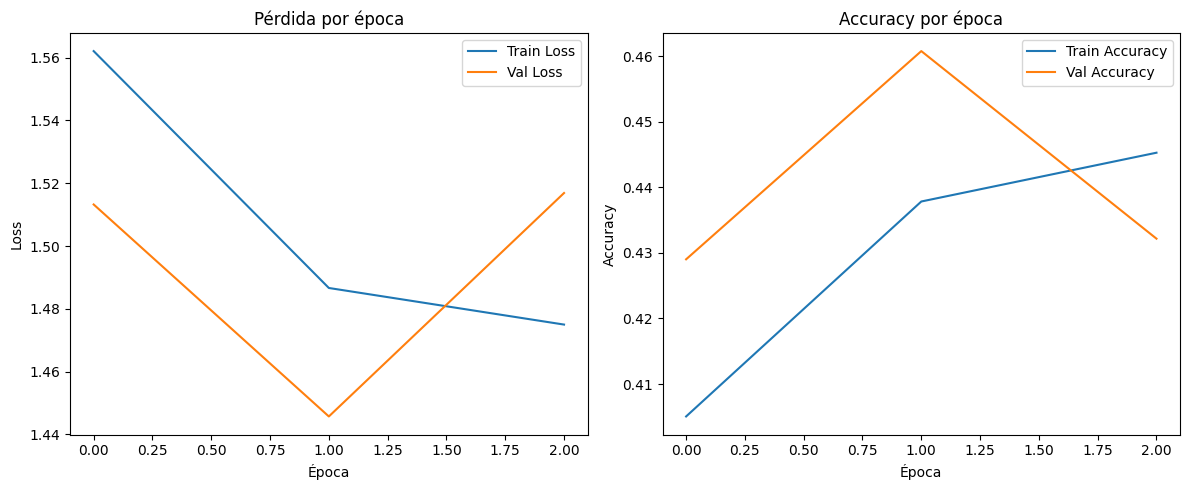

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Pérdida por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Conclusión

En esta etapa se implementó una estrategia de transferencia de aprendizaje con ResNet18 para la clasificación de emociones faciales.  
El propósito fue aprovechar una arquitectura preentrenada para obtener un modelo potencialmente más robusto que la CNN base, reduciendo al mismo tiempo el costo de entrenamiento.  
A partir de los resultados obtenidos en pérdida y precisión, será posible comparar este enfoque con el modelo anterior y evaluar si el uso de una red preentrenada mejora el desempeño general del proyecto.